# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [35]:
#17 campaigns

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [36]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.impute import KNNImputer
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import RandomizedSearchCV

In [37]:
all_bank_data = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [38]:
all_bank_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [39]:
all_bank_data.info()
#based on data.info, it seems there are no null, but there are unknown values, which are essentially null.

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [40]:
#The buisness objective is to understand the factors that identify a contact likely to 
#subscribe to a long-term deposit to reduce the number of contacts required

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [41]:
#Starting by cleaning the data
#Making unknown values into NaN and removing them
all_bank_data_no_unknown = all_bank_data.replace(['unknown', 'N/A'], np.nan)
no_nan_bank_data = all_bank_data_no_unknown.dropna()
no_nan_bank_data.info()

<class 'pandas.DataFrame'>
Index: 30488 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             30488 non-null  int64  
 1   job             30488 non-null  str    
 2   marital         30488 non-null  str    
 3   education       30488 non-null  str    
 4   default         30488 non-null  str    
 5   housing         30488 non-null  str    
 6   loan            30488 non-null  str    
 7   contact         30488 non-null  str    
 8   month           30488 non-null  str    
 9   day_of_week     30488 non-null  str    
 10  duration        30488 non-null  int64  
 11  campaign        30488 non-null  int64  
 12  pdays           30488 non-null  int64  
 13  previous        30488 non-null  int64  
 14  poutcome        30488 non-null  str    
 15  emp.var.rate    30488 non-null  float64
 16  cons.price.idx  30488 non-null  float64
 17  cons.conf.idx   30488 non-null  float64
 18  eu

In [42]:
#Asigning the features to variable X
X = no_nan_bank_data.drop(['y'], axis = 1)

In [43]:
#assigning column y as the variable column
y = no_nan_bank_data.y

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [44]:
#Spliting the data into a training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [45]:
#Here we are implementing a DummyClassifier that only really looks at the prediction variable to make predictions. 
#This will establish our baseline model to outperform
dummy_classifier = ''
baseline_score = ''

    
# YOUR CODE HERE
start_time = time.time() #This is to mark when training starts
dummy_clf = DummyClassifier().fit(X_train, y_train)
training_time = time.time() - start_time #This is to calculate how long training took
baseline_training_score = dummy_clf.score(X_train, y_train)
baseline_test_score = dummy_clf.score(X_test, y_test)

### ANSWER CHECK
print(baseline_score)

#Creating a dataframe to start adding the performance metrics to 
model_performance = {
    'Model': [],
    'Train Time': [],
    'Train Accuracy': [],
    'Test Accuracy': []
}

model_performance = pd.DataFrame(model_performance)

#adding values from above to dataframe
model_performance.loc[len(model_performance)] = ['Dummy Classifier', training_time, baseline_training_score, baseline_test_score]
model_performance

,Model,Train Time,Train Accuracy,Test Accuracy
0,Dummy Classifier,0.018405,0.873918,0.87195


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [46]:
#The initial logistic regression model will not use dummies so it will only look at numeric features

selector = make_column_selector(dtype_include= str)


transformer = make_column_transformer(
    (OneHotEncoder(), selector),
    remainder=StandardScaler())

lgr_1_pipe = Pipeline([
    ('transformer', transformer),
    ('lgr', LogisticRegression())
])
start_time = time.time() #This is to mark when training starts
lgr_1_pipe.fit(X_train, y_train)
training_time = time.time() - start_time #This is to calculate how long training took


### Problem 9: Score the Model

What is the accuracy of your model?

In [47]:
lgr_1_pipe_train_accuracy = lgr_1_pipe.score(X_train, y_train)
lgr_1_pipe_test_accuracy = lgr_1_pipe.score(X_test, y_test)
model_performance.loc[len(model_performance)] = ['Simple LGR', training_time, lgr_1_pipe_train_accuracy, lgr_1_pipe_test_accuracy]
model_performance

,Model,Train Time,Train Accuracy,Test Accuracy
0,Dummy Classifier,0.018405,0.873918,0.871950
1,Simple LGR,0.223571,0.900770,0.904225


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [48]:
#Building a simple KNN Classification model with default values
simple_knn_pipe = Pipeline([
    ('transformer', transformer),
    ('knn', KNeighborsClassifier())
])
start_time = time.time() #This is to mark when training starts
simple_knn_pipe.fit(X_train, y_train)
training_time = time.time() - start_time #This is to calculate how long training took

#Calculating the accuracy and adding that to the table
simple_knn_pipe_train_accuracy = simple_knn_pipe.score(X_train, y_train)
simple_knn_pipe_test_accuracy = simple_knn_pipe.score(X_test, y_test)
model_performance.loc[len(model_performance)] = ['Simple KNN Classifier', training_time, simple_knn_pipe_train_accuracy, simple_knn_pipe_test_accuracy]
model_performance

,Model,Train Time,Train Accuracy,Test Accuracy
0,Dummy Classifier,0.018405,0.873918,0.871950
1,Simple LGR,0.223571,0.900770,0.904225
2,Simple KNN Classifier,0.082391,0.919356,0.890711


In [49]:
#Building a simple decision tree classified
simple_dtree_pipe = Pipeline([
    ('transformer', transformer),
    ('dtree', DecisionTreeClassifier())
])

start_time = time.time() #This is to mark when training starts
simple_dtree_pipe.fit(X_train, y_train)
training_time = time.time() - start_time #This is to calculate how long training took

simple_dtree_pipe_train_accuracy = simple_dtree_pipe.score(X_train, y_train)
simple_dtree_pipe_test_accuracy = simple_dtree_pipe.score(X_test, y_test)
model_performance.loc[len(model_performance)] = ['Simple Deciscion Tree Classifier', training_time, simple_dtree_pipe_train_accuracy, simple_dtree_pipe_test_accuracy]
model_performance

,Model,Train Time,Train Accuracy,Test Accuracy
0,Dummy Classifier,0.018405,0.873918,0.871950
1,Simple LGR,0.223571,0.900770,0.904225
2,Simple KNN Classifier,0.082391,0.919356,0.890711
3,Simple Deciscion Tree Classifier,0.211003,1.000000,0.872212


In [50]:
#Building a simple SVC model with default values
simple_svc_pipe = Pipeline([
    ('transformer', transformer),
    ('svc', SVC())
])
start_time = time.time() #This is to mark when training starts
simple_svc_pipe.fit(X_train, y_train)
training_time = time.time() - start_time #This is to calculate how long training took

simple_svc_pipe_train_accuracy = simple_svc_pipe.score(X_train, y_train)
simple_svc_pipe_test_accuracy = simple_svc_pipe.score(X_test, y_test)
model_performance.loc[len(model_performance)] = ['Simple SVC Classifier', training_time, simple_svc_pipe_train_accuracy, simple_svc_pipe_test_accuracy]
model_performance

,Model,Train Time,Train Accuracy,Test Accuracy
0,Dummy Classifier,0.018405,0.873918,0.871950
1,Simple LGR,0.223571,0.900770,0.904225
2,Simple KNN Classifier,0.082391,0.919356,0.890711
3,Simple Deciscion Tree Classifier,0.211003,1.000000,0.872212
4,Simple SVC Classifier,6.311886,0.914283,0.902388


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

Best Parameters: {'knn__n_neighbors': 201}


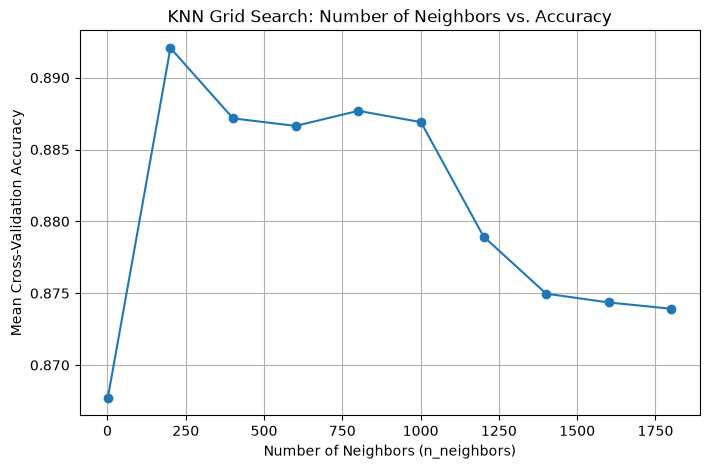

In [52]:
#Going to see if can improve the KNN classifier with a parameter grid search
param_grid = {'knn__n_neighbors': range(1, 2000, 200)}
KNN_grid_search_V1 = GridSearchCV(simple_knn_pipe, param_grid=param_grid)

start_time = time.time() #This is to mark when training starts
KNN_grid_search_V1.fit(X_train, y_train)
training_time = time.time() - start_time #This is to calculate how long training took

print("Best Parameters:", KNN_grid_search_V1.best_params_)

results = pd.DataFrame(KNN_grid_search_V1.cv_results_)

#Adding the accuracy of the best KNN nearest neighbors from V1
KNN_grid_search_V1_train_accuracy = KNN_grid_search_V1.score(X_train, y_train)
KNN_grid_search_V1_test_accuracy = KNN_grid_search_V1.score(X_test, y_test)

model_performance.loc[len(model_performance)] = ['KNN nearest neighbors grid search 1', training_time, KNN_grid_search_V1_train_accuracy, KNN_grid_search_V1_test_accuracy]
model_performance

# Plot n_neighbors vs validation accuracy to see if can make improvements
plt.figure(figsize=(8, 5))
plt.plot(results['param_knn__n_neighbors'], results['mean_test_score'], marker='o', linestyle='-')
plt.title('KNN Grid Search: Number of Neighbors vs. Accuracy')
plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

Best Parameters: {'knn__n_neighbors': 19}


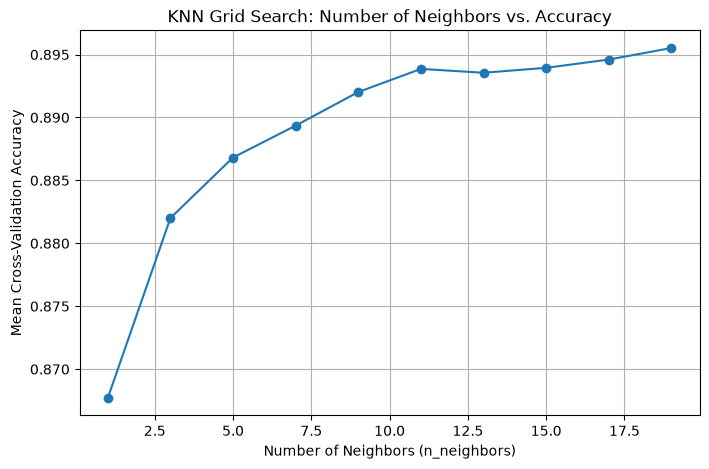

In [53]:
#Based on the above KNN_grid search going to do another looking at up to 500, then kept running the code until narrowed down the platoue happening around 20
param_grid = {'knn__n_neighbors': range(1, 20, 2)}
KNN_grid_search_V2 = GridSearchCV(simple_knn_pipe, param_grid=param_grid)

start_time = time.time() #This is to mark when training starts
KNN_grid_search_V2.fit(X_train, y_train)
training_time = time.time() - start_time #This is to calculate how long training took

print("Best Parameters:", KNN_grid_search_V2.best_params_)

#Adding the accuracy of the best KNN nearest neighbors from V2
KNN_grid_search_V2_train_accuracy = KNN_grid_search_V2.score(X_train, y_train)
KNN_grid_search_V2_test_accuracy = KNN_grid_search_V2.score(X_test, y_test)


model_performance.loc[len(model_performance)] = ['KNN nearest neighbors grid search 2', training_time, KNN_grid_search_V2_train_accuracy, KNN_grid_search_V2_test_accuracy]
model_performance

results = pd.DataFrame(KNN_grid_search_V2.cv_results_)

# Plot n_neighbors vs validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(results['param_knn__n_neighbors'], results['mean_test_score'], marker='o', linestyle='-')
plt.title('KNN Grid Search: Number of Neighbors vs. Accuracy')
plt.xlabel('Number of Neighbors (n_neighbors)')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [54]:
#Now going to do some parameter searching for the decision tree
param_grid = {
    'dtree__min_impurity_decrease': [0.01, 0.02, 0.03, 0.05], 
    'dtree__max_depth': [2, 5, 10], 
    'dtree__min_samples_split': [0.1, 0.2, 0.05]
}

decision_tree_v1 = GridSearchCV(simple_dtree_pipe, param_grid=param_grid)

start_time = time.time() #This is to mark when training starts
decision_tree_v1.fit(X_train, y_train)
training_time = time.time() - start_time #This is to calculate how long training took

print("Best Parameters:", decision_tree_v1.best_params_)

results = pd.DataFrame(decision_tree_v1.cv_results_)

#Adding the accuracy of the best KNN nearest neighbors from V1
Dtree_grid_search_V1_train_accuracy = decision_tree_v1.score(X_train, y_train)
Dtree_grid_search_V1_test_accuracy = decision_tree_v1.score(X_test, y_test)

model_performance.loc[len(model_performance)] = ['Deciscion tree grid search 1', training_time, Dtree_grid_search_V1_train_accuracy, Dtree_grid_search_V1_test_accuracy]



Best Parameters: {'dtree__max_depth': 2, 'dtree__min_impurity_decrease': 0.01, 'dtree__min_samples_split': 0.1}


In [55]:
model_performance

,Model,Train Time,Train Accuracy,Test Accuracy
0,Dummy Classifier,0.018405,0.873918,0.871950
1,Simple LGR,0.223571,0.900770,0.904225
2,Simple KNN Classifier,0.082391,0.919356,0.890711
3,Simple Deciscion Tree Classifier,0.211003,1.000000,0.872212
4,Simple SVC Classifier,6.311886,0.914283,0.902388
5,KNN nearest neighbors grid search 1,41.691243,0.893335,0.895697
6,KNN nearest neighbors grid search 1,37.077286,0.893335,0.895697
7,KNN nearest neighbors grid search 2,7.393353,0.904487,0.898583
8,Deciscion tree grid search 1,11.040072,0.892023,0.891236


In [63]:
#Since the simple logistic regression model is one of the best performing models (depending on the run) want to see what the coefficients 
#are to gain some buisness insight

trained_model = lgr_1_pipe.named_steps['lgr']
feature_names = lgr_1_pipe.named_steps['transformer'].get_feature_names_out()


#Extract coefficients and intercept
coefficients = trained_model.coef_[0]


#Pair coefficients with feature names for readability
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)


print(coef_df)





                                         Feature  Coefficient
34                      onehotencoder__month_mar     1.681656
48                           remainder__duration     1.200653
53                     remainder__cons.price.idx     1.141324
30                      onehotencoder__month_aug     0.479722
18           onehotencoder__education_illiterate     0.468233
55                          remainder__euribor3m     0.464558
56                        remainder__nr.employed     0.293994
5                     onehotencoder__job_retired     0.277794
46               onehotencoder__poutcome_success     0.203421
8                     onehotencoder__job_student     0.200558
54                      remainder__cons.conf.idx     0.085872
43                onehotencoder__day_of_week_wed     0.079750
9                  onehotencoder__job_technician     0.065582
31                      onehotencoder__month_dec     0.021865
38                      onehotencoder__month_sep     0.005980
27      

In [ ]:
#In the future the buisness can use the logistic regression pipeline to predict if someone is likely to sign up
#but if they don't have the pipeline for some reason, March is a very successful month for calls, the longer the call
#duration the more successful it is to be, and the price is very important for predicting if they will sign on.

##### Questions